In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [8]:
df = pd.read_csv("googleplaystore.csv")

In [9]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [11]:
df.shape

(10841, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [13]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


<div style="padding: 20px; border-radius: 15px; background-color: #f8f9fa; border-left: 8px solid #3498db; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <h2 style="color: #2c3e50; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin-top: 0;">
        🔍 İlk Bakış: Verinin Keşfi ve Kısıtlamalar
    </h2>
    <p style="font-size: 1.1em; color: #34495e; line-height: 1.6;">
        Veri setini yükledikten sonra ilk işimiz <code>df.describe()</code> fonksiyonu ile istatistiksel bir özet çıkarmaktı. Ancak burada kritik bir "sorun" ile karşılaştık.
    </p>
    <div style="background-color: #fff; padding: 15px; border-radius: 10px; border: 1px dashed #e67e22;">
        <strong style="color: #e67e22;">⚠️ Kritik Gözlem:</strong><br>
        Normal şartlarda <i>Size, Installs, Price</i> ve <i>Reviews</i> gibi sütunların sayısal (numeric) olması gerekirken, özet tabloda sadece <b>Rating</b> sütunu sayısal istatistikleriyle görünüyor.
    </div>
    <p style="margin-top: 15px; font-style: italic; color: #7f8c8d;">
        <b>Neden?</b> Çünkü diğer tüm sütunlar veri setinde "Object" (string/metin) tipinde tutuluyor. İçerdikleri $, M, k, + gibi karakterler analiz yapmamızı engelliyor.
    </p>
    <p style="font-weight: bold; color: #2980b9; border-top: 1px solid #dcdde1; padding-top: 10px;">
        🚀 Hedefimiz: Veri temizleme operasyonuyla bu "metin" yığınlarını sayısal verilere dönüştürüp, veriyi gerçek analiz edilebilir formuna kavuşturmak!
    </p>
</div>

In [22]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [24]:
df["Reviews"].value_counts()

Reviews
0         596
1         272
2         214
3         175
4         137
         ... 
342912      1
4272        1
5517        1
4057        1
398307      1
Name: count, Length: 6002, dtype: int64

In [26]:
df["Reviews"].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [28]:
df["Reviews"].str.isnumeric().sum()

10840

In [30]:
df[~df["Reviews"].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [32]:
df_clean = df.copy()

In [34]:
df_clean = df_clean.drop(df_clean.index[10472])

<div style="padding: 15px; border-radius: 8px; background-color: #fdfdfd; border: 1px solid #e0e0e0; border-left: 5px solid #2c3e50;">
    <h4 style="margin-top: 0; color: #2c3e50;">🛠️ Veri Temizleme</h4>
    <p style="margin-bottom: 0; color: #444;">
        Veri setindeki 10.841 satır içerisinden sadece <b>1 değer</b> yapısal sorun çıkarttığı için direkt veri setinden çıkartılmıştır.
    </p>
</div>

In [37]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  object 
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.2+ MB


In [39]:
df_clean["Reviews"] = df_clean["Reviews"].astype(int)

In [41]:
df_clean.describe()

,Rating,Reviews
count,9366.000000,1.084000e+04
mean,4.191757,4.441529e+05
std,0.515219,2.927761e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.477550e+04
max,5.000000,7.815831e+07


<div style="padding: 15px; border-radius: 8px; background-color: #f0f7ff; border: 1px solid #d0e2ff; border-left: 5px solid #007bff;">
    <h4 style="margin-top: 0; color: #0056b3;">✅ Reviews Tamam, Sıra Boyut (Size) Analizinde</h4>
    <p style="margin-bottom: 0; color: #333;">
        <code>Reviews</code> sütununu başarılı bir şekilde sayısal formata dönüştürdük. Şimdi ise veri setindeki en karmaşık sütunlardan biri olan <b>Size</b> sütununa odaklanıyoruz. Bu aşamada farklı birimlerin (M, k) standardize edilmesi ve "Varies with device" gibi metinsel ifadelerin yönetilmesi gerekiyor.
    </p>
</div>

In [44]:
df_clean["Size"].value_counts()

Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
                      ... 
430k                     1
429k                     1
200k                     1
460k                     1
619k                     1
Name: count, Length: 461, dtype: int64

In [46]:
df_clean["Size"] = df_clean["Size"].str.replace("M","000")
df_clean["Size"] = df_clean["Size"].str.replace("k","")

In [48]:
df_clean["Size"].unique()

array(['19000', '14000', '8.7000', '25000', '2.8000', '5.6000', '29000',
       '33000', '3.1000', '28000', '12000', '20000', '21000', '37000',
       '2.7000', '5.5000', '17000', '39000', '31000', '4.2000', '7.0000',
       '23000', '6.0000', '6.1000', '4.6000', '9.2000', '5.2000', '11000',
       '24000', 'Varies with device', '9.4000', '15000', '10000',
       '1.2000', '26000', '8.0000', '7.9000', '56000', '57000', '35000',
       '54000', '201', '3.6000', '5.7000', '8.6000', '2.4000', '27000',
       '2.5000', '16000', '3.4000', '8.9000', '3.9000', '2.9000', '38000',
       '32000', '5.4000', '18000', '1.1000', '2.2000', '4.5000', '9.8000',
       '52000', '9.0000', '6.7000', '30000', '2.6000', '7.1000', '3.7000',
       '22000', '7.4000', '6.4000', '3.2000', '8.2000', '9.9000',
       '4.9000', '9.5000', '5.0000', '5.9000', '13000', '73000', '6.8000',
       '3.5000', '4.0000', '2.3000', '7.2000', '2.1000', '42000',
       '7.3000', '9.1000', '55000', '23', '6.5000', '1.5000', '7

In [50]:
df_clean["Size"] = df_clean["Size"].replace("Varies with device",np.nan)

In [52]:
df_clean["Size"] = df_clean["Size"].astype(float)

In [54]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int32(1), object(10)
memory usage: 1.1+ MB


<div style="padding: 15px; border-radius: 8px; background-color: #fafafa; border: 1px solid #ddd; border-left: 5px solid #27ae60;">
    <h4 style="margin-top: 0; color: #27ae60;">📏 Boyut (Size) Standardizasyonu</h4>
    <p style="margin-bottom: 0; color: #444;">
        Uygulama boyutlarını analiz edebilmek için <b>M</b> (Megabyte) yerine <code>000</code> yazıp, <b>k</b> (Kilobyte) eklerini kaldırarak <b>1000k = 1M</b> mantığıyla tüm verileri aynı birime getirdik. Böylece metin tabanlı boyut verilerini sayısal (float) değerlere dönüştürmeyi başardık.
    </p>
</div>

In [56]:
df_clean["Installs"].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Name: count, dtype: int64

In [58]:
df_clean["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [60]:
df_clean["Price"].value_counts()

Price
0         10040
$0.99       148
$2.99       129
$1.99        73
$4.99        72
          ...  
$19.90        1
$1.75         1
$14.00        1
$4.85         1
$1.04         1
Name: count, Length: 92, dtype: int64

In [62]:
chars_to_remove = ["+",",","$"]
cols_to_clean= ["Installs","Price"]

In [64]:
for char in chars_to_remove:
    for cols in cols_to_clean:
        df_clean[cols] = df_clean[cols].str.replace(char,"")

In [66]:
df_clean["Price"].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26',
       '1.20', '1.04'], dtype=object)

In [68]:
df_clean["Installs"].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [70]:
df_clean["Price"] = df_clean["Price"].astype(float)

In [72]:
df_clean["Installs"] = df_clean["Installs"].astype(float)

In [74]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  float64
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(4), int32(1), object(8)
memory usage: 1.1+ MB


In [76]:
df_clean.describe()

,Rating,Reviews,Size,Installs,Price
count,9366.000000,1.084000e+04,9145.000000,1.084000e+04,10840.000000
mean,4.191757,4.441529e+05,19579.419913,1.546434e+07,1.027368
std,0.515219,2.927761e+06,24042.062020,8.502936e+07,15.949703
min,1.000000,0.000000e+00,1.000000,0.000000e+00,0.000000
25%,4.000000,3.800000e+01,5.600000,1.000000e+03,0.000000
50%,4.300000,2.094000e+03,13000.000000,1.000000e+05,0.000000
75%,4.500000,5.477550e+04,30000.000000,5.000000e+06,0.000000
max,5.000000,7.815831e+07,100000.000000,1.000000e+09,400.000000


<div style="padding: 15px; border-radius: 8px; background-color: #f9f9f9; border: 1px solid #eee; border-left: 5px solid #f1c40f;">
    <h4 style="margin-top: 0; color: #d4ac0d;">🧹 Karakter Temizliği ve Veri Dönüşümü</h4>
    <p style="margin-bottom: 0; color: #333;">
        Analiz sürecini engelleyen <code>Price</code> ve <code>Installs</code> sütunlarındaki özel karakterleri (<b>+</b>, <b>$</b> ve <b>,</b>) temizledik. Bu sayede uygulamaların <b>fiyatlandırma ve indirilme istatistiklerini</b> tamamen sayısal verilere dönüştürerek analize hazır hale getirdik.
    </p>
</div>

In [78]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [80]:
df_clean["Last Updated"]

0         January 7, 2018
1        January 15, 2018
2          August 1, 2018
3            June 8, 2018
4           June 20, 2018
               ...       
10836       July 25, 2017
10837        July 6, 2018
10838    January 20, 2017
10839    January 19, 2015
10840       July 25, 2018
Name: Last Updated, Length: 10840, dtype: object

In [82]:
df_clean["Last Updated"] = pd.to_datetime(df_clean["Last Updated"])

<div style="padding: 15px; border-radius: 8px; background-color: #f4f4f4; border: 1px solid #ddd; border-left: 5px solid #673ab7;">
    <h4 style="margin-top: 0; color: #673ab7;">📅 Tarih Formatı Düzenleme</h4>
    <p style="margin-bottom: 0; color: #333;">
        Uygulamaların son güncelleme tarihlerini içeren <code>Last Updated</code> sütununu <b>datetime</b> formatına dönüştürdük. Bu sayede zaman serisi analizleri yapabilir ve uygulamaların güncellik durumlarını kronolojik olarak inceleyebilir hale geldik.
    </p>
</div>

In [84]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [86]:
df_clean["Day"] = df_clean["Last Updated"].dt.day
df_clean["Month"] = df_clean["Last Updated"].dt.month
df_clean["Year"] = df_clean["Last Updated"].dt.year

In [88]:
df_clean.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [90]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int32         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  float64       
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

In [92]:
df_clean[df_clean.duplicated("App")].shape

(1181, 16)

In [94]:
df_clean = df_clean.drop_duplicates(subset=["App"])

In [96]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9659 non-null   object        
 1   Category        9659 non-null   object        
 2   Rating          8196 non-null   float64       
 3   Reviews         9659 non-null   int32         
 4   Size            8432 non-null   float64       
 5   Installs        9659 non-null   float64       
 6   Type            9658 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9659 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9651 non-null   object        
 12  Android Ver     9657 non-null   object        
 13  Day             9659 non-null   int32         
 14  Month           9659 non-null   int32         
 15  Year    

<div style="padding: 15px; border-radius: 8px; background-color: #fff4e6; border: 1px solid #ffd8a8; border-left: 5px solid #fd7e14;">
    <h4 style="margin-top: 0; color: #d9480f;">👯 Duplicates Temizliği</h4>
    <p style="margin-bottom: 10px; color: #333;">
        Analizimizin doğruluğunu korumak için veri setindeki mükerrer kayıtları ele aldık. Aynı isimdeki uygulamaların birden fazla kez listelenmesi, toplam indirilme ve kategori bazlı analizlerde yanıltıcı sonuçlar doğurabilirdi.
    </p>
    <ul style="color: #444; font-size: 0.95em;">
        <li><b>Sorun:</b> Bazı popüler uygulamaların farklı zamanlarda kaydedilmiş birden fazla kopyası bulunuyordu.</li>
        <li><b>Çözüm:</b> <code>drop_duplicates</code> metodunu kullanarak, her uygulamadan sadece birer adet (en güncel veri olacak şekilde) kalmasını sağladık.</li>
    </ul>
    <p style="margin-top: 10px; font-weight: bold; color: #e67e22;">
        Sonuç: Veri setimiz "tekil" hale getirilerek manipülasyondan arındırıldı.
    </p>
</div>

In [98]:
numeric_features = df_clean.select_dtypes(include=['number']).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()

In [100]:
print(numeric_features)

['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']


In [102]:
print(categorical_features)

['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


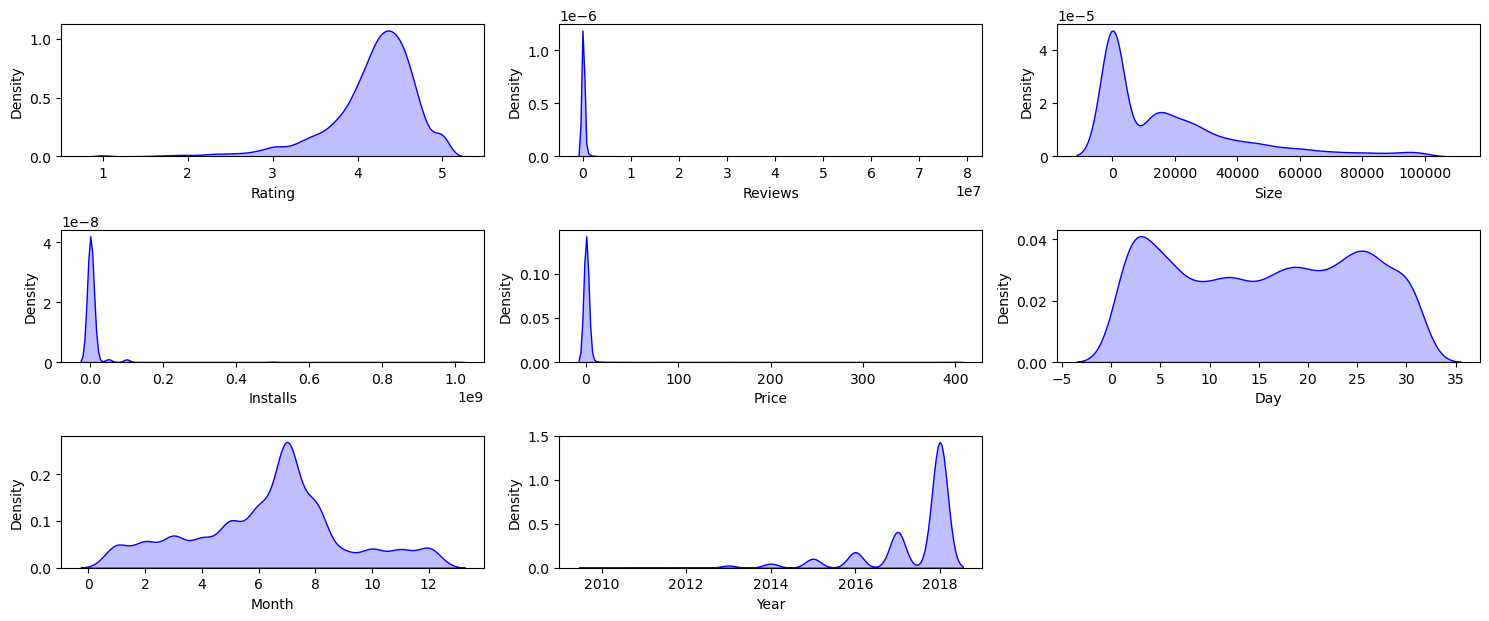

In [104]:
plt.figure(figsize=(15,10))

for i in range (0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_clean[numeric_features[i]], color = "b", fill=True)
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
plt.show()

<div style="padding: 15px; border-radius: 12px; background-color: #f8f9fa; border: 1px solid #e9ecef; border-left: 6px solid #3498db;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 Sayısal Verilerin Dağılım Analizi</h3>
    <p style="color: #555; line-height: 1.6;">
        Sayısal değişkenlerimizin (Rating, Reviews, Size, Installs, Price) dağılımını incelediğimizde pazarın yapısına dair kritik içgörüler elde ediyoruz:
    </p>
    <ul style="color: #444; font-size: 0.95em;">
        <li><b>Rating (Puanlama):</b> Grafikteki yoğunluk 4.0 ile 4.5 arasında zirve yapıyor. Bu, kullanıcıların genel olarak pozitif deneyim yaşadığını veya beklentilerini karşılayan uygulamaların markette kalıcı olduğunu gösteriyor.</li>
        <li><b>Reviews & Installs:</b> Her iki grafik de "Sağa Çarpık" (Right-Skewed) bir yapı sergiliyor. Bu durum, pazarın "kazanan her şeyi alır" dinamiğine sahip olduğunu; çok az sayıda uygulamanın milyonlarca etkileşim alırken, büyük çoğunluğun düşük hacimde kaldığını kanıtlıyor.</li>
        <li><b>Price (Fiyatlandırma):</b> Dağılımın neredeyse tamamı 0 noktasında toplanmış durumda. Bu, Google Play Store'un ezici bir çoğunlukla "Ücretsiz" uygulama ekosistemine sahip olduğunu gösteriyor.</li>
    </ul>
</div>

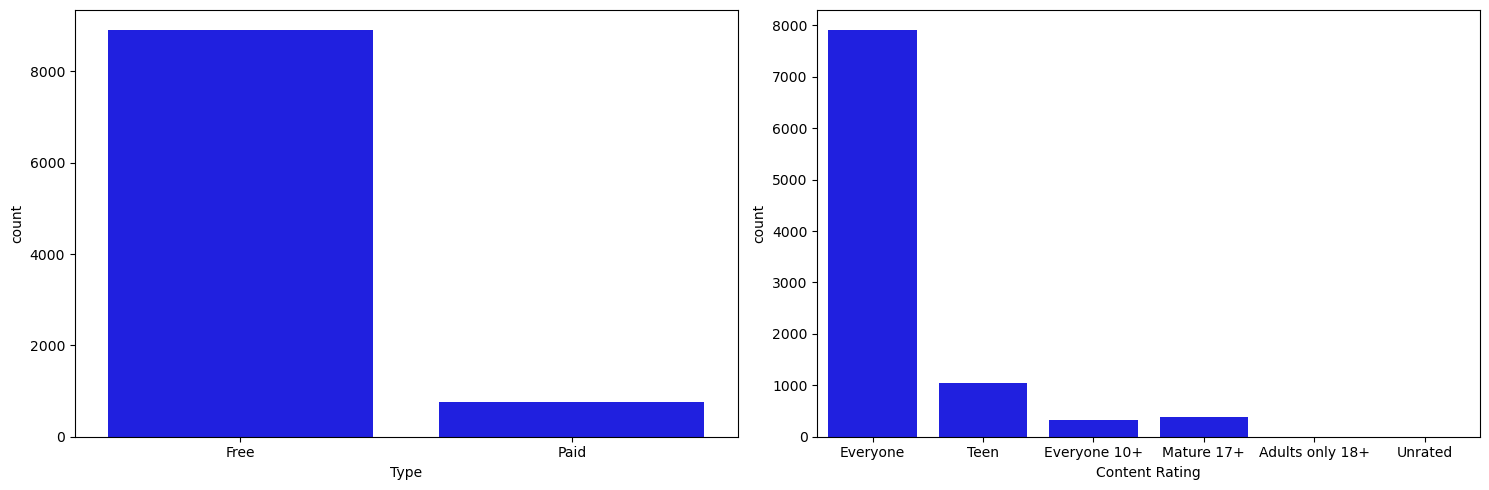

In [105]:
plt.figure(figsize=(15,5))

category = ["Type", "Content Rating"]
for i in range (0, len(category)):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=df_clean[category[i]], color = "b", fill=True)
    plt.xlabel(category[i])
    plt.tight_layout()
plt.show()

<div style="padding: 15px; border-radius: 12px; background-color: #fdf2f2; border: 1px solid #fee2e2; border-left: 6px solid #e74c3c;">
    <h3 style="color: #c0392b; margin-top: 0;">🏬 Market Kompozisyonu ve Hedef Kitle</h3>
    <p style="color: #555; line-height: 1.6;">
        Uygulama tiplerini ve içerik derecelendirmelerini görselleştirdiğimizde hedef kitle stratejileri netleşiyor:
    </p>
    <ul style="color: #444; font-size: 0.95em;">
        <li><b>Ücretsiz vs Ücretli:</b> Marketin %90'ından fazlası ücretsiz modellerden oluşuyor. Bu da geliştiricilerin doğrudan satış yerine reklam veya uygulama içi satın alma (freemium) modellerine yöneldiğini gösteriyor.</li>
        <li><b>İçerik Derecelendirmesi:</b> "Everyone" (Herkes) kategorisi açık ara lider. Bu, geliştiricilerin maksimum erişim sağlamak için uygulamalarını genel kitleye uygun tasarladığının bir göstergesi.</li>
    </ul>
</div>

In [106]:
df_clean["Category"].value_counts()

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [107]:
df_cat_installs = df_clean.groupby(["Category"])["Installs"].sum().sort_values(ascending= False).reset_index()

In [108]:
df_cat_installs

,Category,Installs
0,GAME,1.387892e+10
1,COMMUNICATION,1.103828e+10
2,TOOLS,8.001772e+09
3,PRODUCTIVITY,5.793091e+09
4,SOCIAL,5.487868e+09
5,PHOTOGRAPHY,4.649148e+09
6,FAMILY,4.427942e+09
7,VIDEO_PLAYERS,3.926903e+09
8,TRAVEL_AND_LOCAL,2.894887e+09
9,NEWS_AND_MAGAZINES,2.369218e+09


In [109]:
df_cat_installs["Installs"] = df_cat_installs["Installs"]/100000

In [110]:
df_cat_installs

,Category,Installs
0,GAME,138789.24415
1,COMMUNICATION,110382.76251
2,TOOLS,80017.71915
3,PRODUCTIVITY,57930.91369
4,SOCIAL,54878.67902
5,PHOTOGRAPHY,46491.47655
6,FAMILY,44279.41505
7,VIDEO_PLAYERS,39269.02720
8,TRAVEL_AND_LOCAL,28948.87146
9,NEWS_AND_MAGAZINES,23692.17760


<div style="padding: 15px; border-radius: 10px; background-color: #f8f9fa; border: 1px solid #dee2e6; border-left: 6px solid #2ecc71;">
    <h3 style="color: #27ae60; margin-top: 0;">📊 Kategori Bazlı Toplam İndirilme Analizi</h3>
    <p style="color: #333; line-height: 1.6;">
        Uygulamaları kategorilerine göre gruplayıp toplam indirilme sayılarını (<code>Installs</code>) büyükten küçüğe sıraladığımızda, pazarın gerçek liderini belirledik.
    </p>
    <div style="background-color: #fff; padding: 10px; border-radius: 5px; border: 1px dashed #2ecc71; margin-bottom: 10px;">
        <strong>🏆 Zirvedeki Kategori: GAME</strong><br>
        Yapılan analiz sonucunda <b>GAME (Oyun)</b> kategorisi, toplam indirilme sayısıyla tüm kategorileri geride bırakarak marketin en çok talep gören ve en yüksek trafik hacmine sahip alanı olduğunu kanıtlamıştır.
    </div>
    <p style="color: #555; font-size: 0.95em;">
        Bu veri, Google Play Store ekosisteminde kullanıcı etkileşiminin ve indirme potansiyelinin en yoğun olduğu noktanın eğlence ve oyun sektörü olduğunu göstermektedir.
    </p>
</div>

In [111]:
apps = ["GAME","COMMUNICATION","TOOLS","PRODUCTIVITY","SOCIAL"]

In [112]:
df_app_category = df_clean.groupby(["Category","App"])["Installs"].sum().reset_index()

In [113]:
df_app_category = df_app_category.sort_values("Installs", ascending=False)

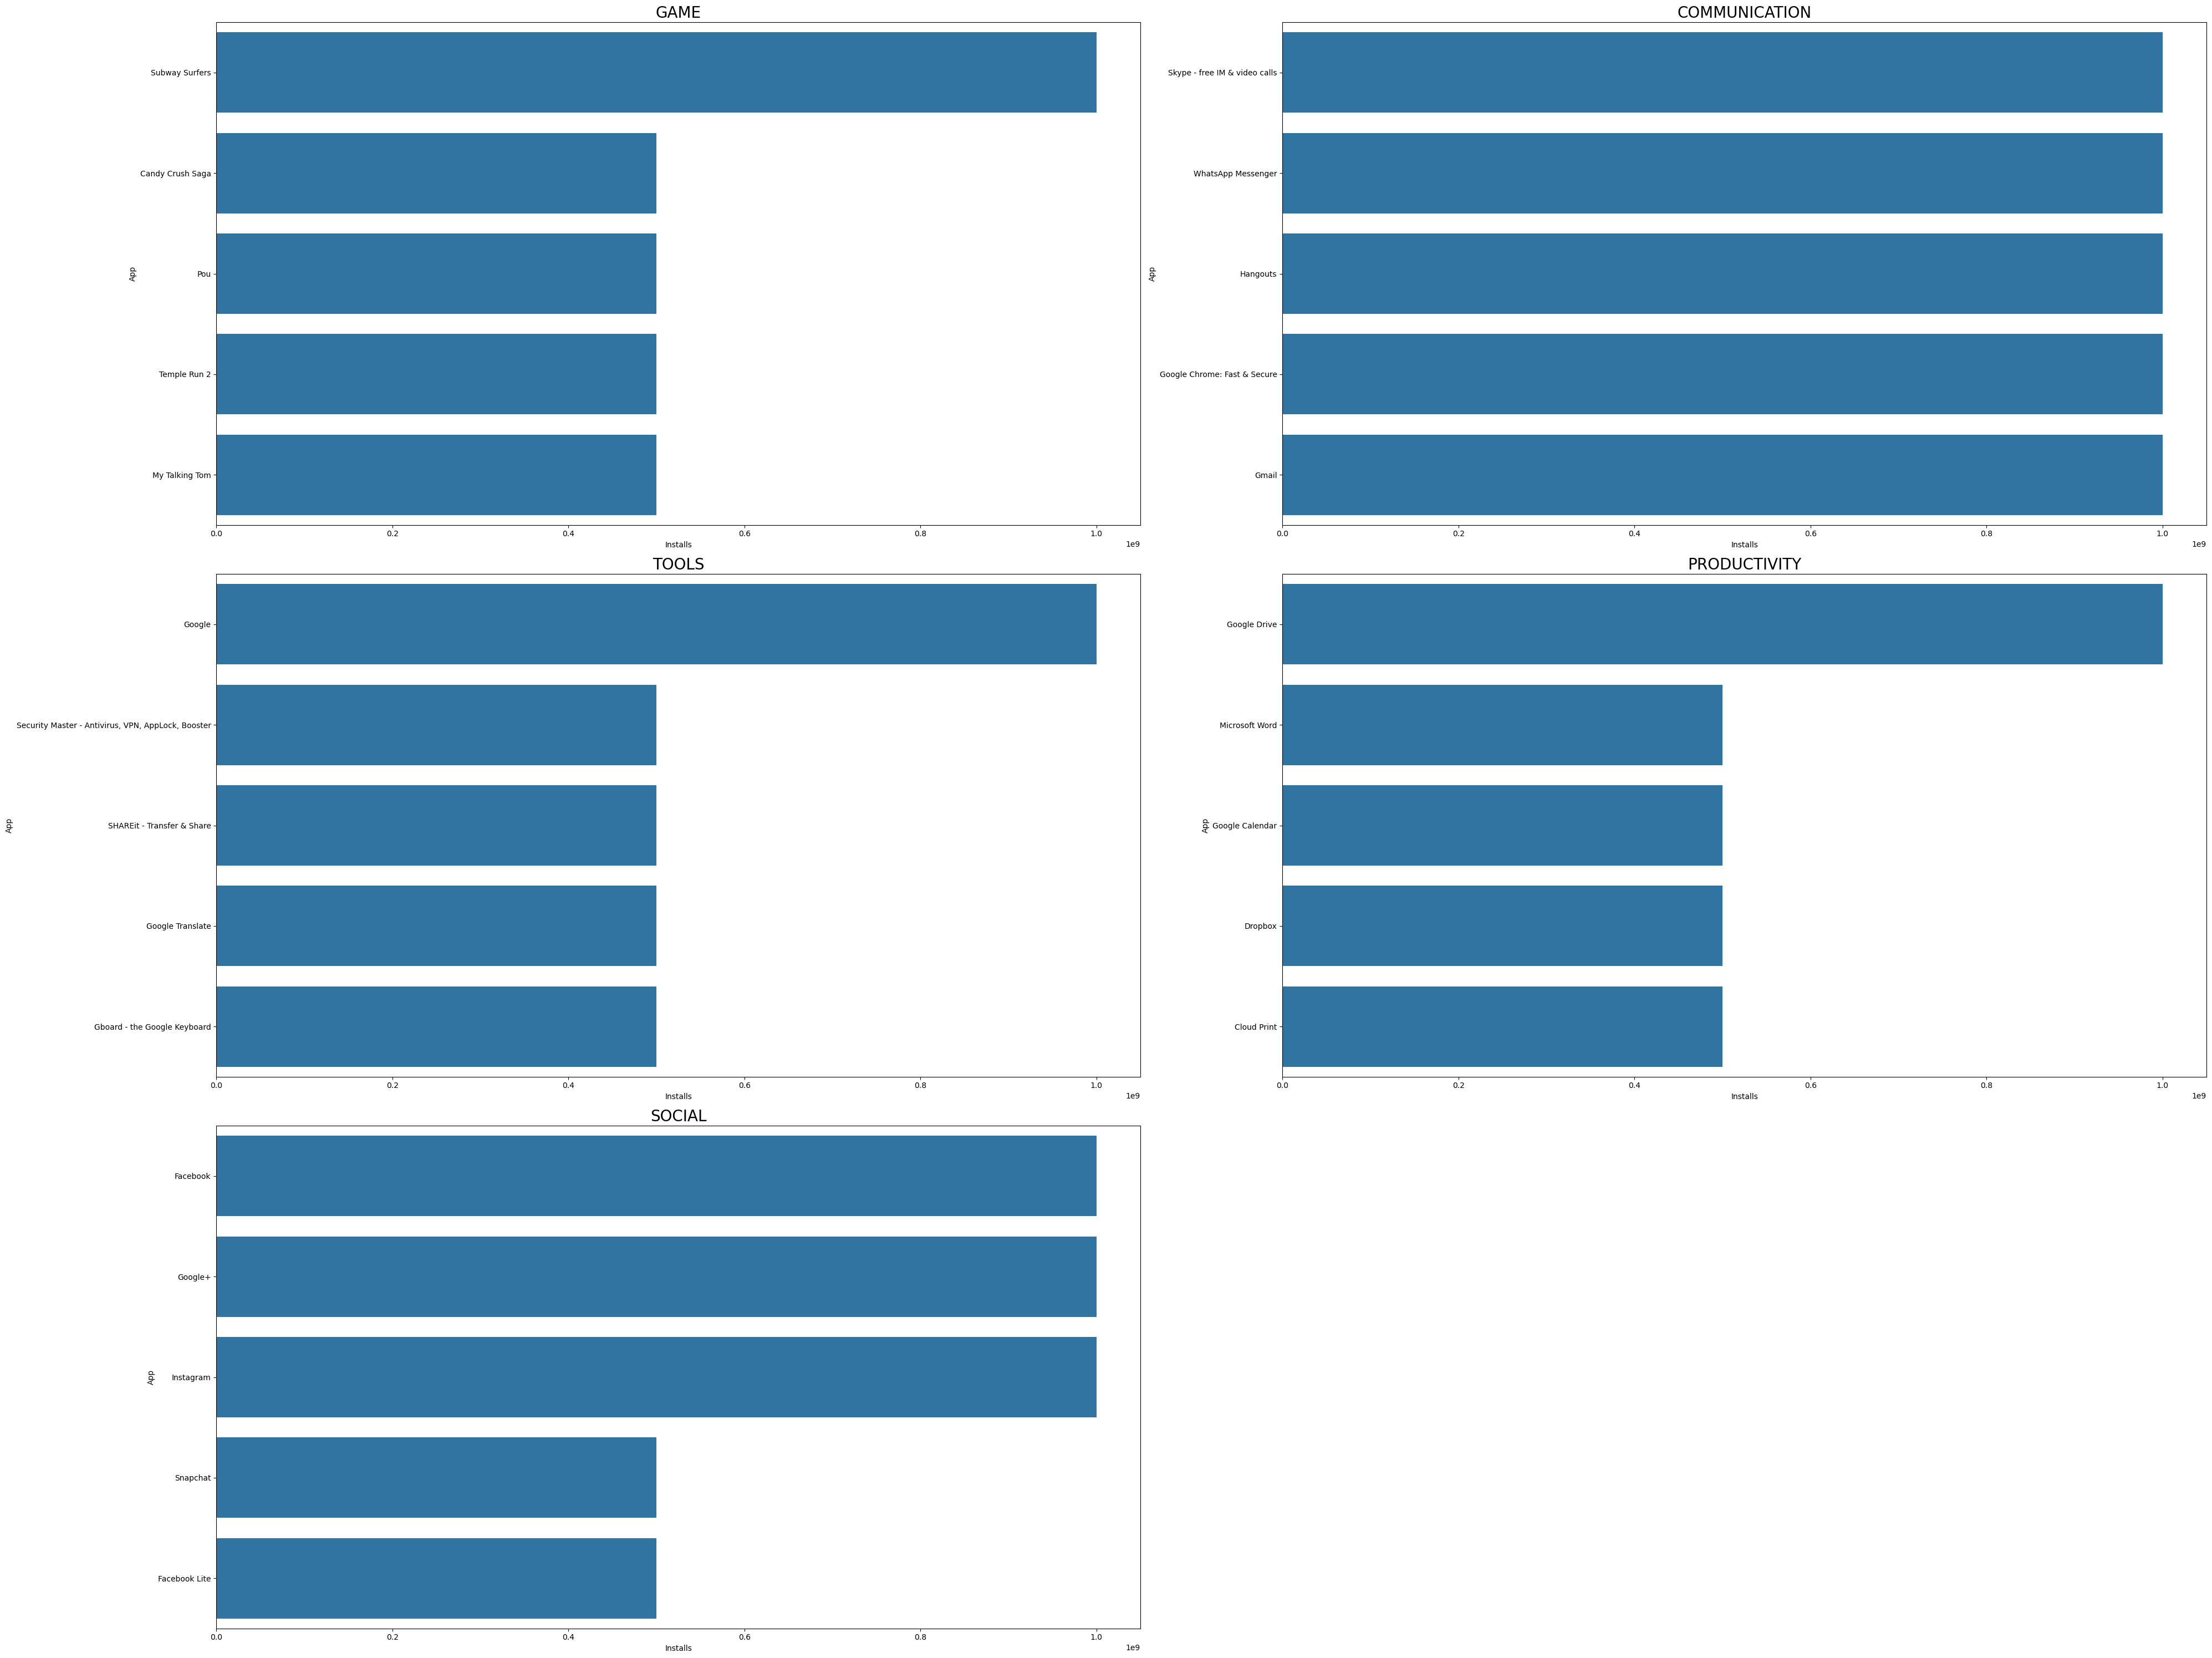

In [114]:
plt.figure(figsize=(40,30))
for i, app in enumerate(apps):
    df2 = df_app_category[df_app_category.Category == app]
    df2 = df2.head(5)
    #print(df2)

    plt.subplot(3,2,i+1)
    sns.barplot(data=df2, x="Installs", y="App")
    plt.title(app, size=20)
plt.tight_layout()
plt.show()

<div style="padding: 18px; border-radius: 12px; background-color: #fff; border: 1px solid #e1e8ed; border-left: 6px solid #1da1f2; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h3 style="color: #1a91da; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">🏆 Kategori Liderleri: Top 5 Uygulama Analizi</h3>
    <p style="color: #444; line-height: 1.6;">
        Kategorilerin toplam hacmini belirledikten sonra, analizi bir adım daha derinleştirerek her kategorinin <b>en çok indirilen ilk 5 uygulamasını</b> görselleştirdik. Bu çalışma, kategorilerdeki "tekel" yapısını veya rekabet dengesini anlamamızı sağlıyor:
    </p>
    <div style="display: flex; gap: 15px; margin-top: 10px;">
        <div style="flex: 1; background: #f8f9fa; padding: 12px; border-radius: 8px;">
            <strong style="color: #2c3e50;">🕹️ Game Kategorisi Gücü</strong><br>
            <span style="font-size: 0.9em; color: #555;">
                Pazarın lideri olan <b>GAME</b> kategorisindeki ilk 5 uygulama, diğer pek çok kategorinin toplamından daha fazla indirilme hacmine sahip.
            </span>
        </div>
        <div style="flex: 1; background: #f8f9fa; padding: 12px; border-radius: 8px;">
            <strong style="color: #2c3e50;">📊 Rekabet Yoğunluğu</strong><br>
            <span style="font-size: 0.9em; color: #555;">
                Grafiklerdeki bar uzunluklarının birbirine yakınlığı, kategorideki rekabetin ne kadar sert olduğunu; bir barın çok uzun olması ise o kategoride tek bir uygulamanın domine ettiğini gösteriyor.
            </span>
        </div>
    </div>
    <p style="margin-top: 15px; border-top: 1px solid #eee; padding-top: 10px; font-weight: bold; color: #2c3e50;">
        💡 Analiz Notu: Bu görselleştirme, yeni bir uygulama geliştirilirken hangi "devlerle" rekabet edileceğini açıkça ortaya koymaktadır.
    </p>
</div>

In [115]:
rating_df = df_clean.groupby(["Category","Installs","App"])["Rating"].sum().sort_values(ascending=False).reset_index()

In [116]:
five_rated_apps = rating_df[rating_df["Rating"] == 5.0]

In [117]:
five_rated_apps.shape

(271, 4)

<div style="padding: 15px; border-radius: 10px; background-color: #fffde7; border: 1px solid #fff9c4; border-left: 6px solid #fbc02d;">
    <h3 style="color: #f57f17; margin-top: 0;">🌟 Final Analizi: Kusursuz Puanlı Uygulamalar</h3>
    <p style="color: #444; line-height: 1.6;">
        Tüm veri setini filtreleyerek kullanıcılarından tam not almayı başaran "elit" grubu belirledik:
    </p>
    <div style="background-color: #ffffff; padding: 12px; border-radius: 8px; border: 1px solid #fff176; text-align: center;">
        <span style="font-size: 1.2em; font-weight: bold; color: #f57f17;">
            🎯 Toplam 271 Uygulama (Rating: 5.0)
        </span>
    </div>
    <p style="margin-top: 10px; color: #555; font-size: 0.95em;">
        10.000'den fazla kayıt arasından sadece <b>271 uygulamanın</b> hata payı olmaksızın 5.0 tam puana sahip olması, Google Play Store ekosisteminde kullanıcı memnuniyetinin zirvesine ulaşmanın ne kadar zorlu ve seçici bir başarı olduğunu kanıtlamaktadır.
    </p>
</div>

<div style="padding: 25px; border-radius: 15px; background-color: #1e272e; color: #ffffff; box-shadow: 0 10px 20px rgba(0,0,0,0.2); border: 1px solid #34495e; font-family: sans-serif;">
<h2 style="color: #3498db; margin-top: 0; border-bottom: 2px solid #3498db; padding-bottom: 10px;">🚀 Proje Genel Özeti: Google Play Store Analiz Raporu</h2>
<p style="font-size: 1.1em; line-height: 1.7; color: #dcdde1;">Bu proje, Google Play Store ekosistemindeki <b>10.000'den fazla uygulamayı</b> kapsayan kapsamlı bir keşifsel veri analizi (EDA) çalışmasıdır. Veri setindeki gürültülü verilerin temizlenmesinden, pazar liderlerinin tespitine kadar olan süreç uçtan uca yönetilmiştir.</p>
<div style="background: rgba(52, 152, 219, 0.1); padding: 15px; border-radius: 10px; border: 1px solid #3498db; margin-bottom: 15px;">
<strong style="color: #3498db; font-size: 1.2em;">🛠️ Teknik Süreç</strong>
<ul style="margin-top: 10px; padding-left: 20px; font-size: 0.95em; color: #ecf0f1;">
<li><b>Veri Hijyeni:</b> Hatalı kayıtlar ve mükerrer (duplicate) veriler elenerek %100 doğruluk sağlandı.</li>
<li><b>Tip Dönüşümü:</b> Karmaşık metin verileri (M, k, $, +) analiz edilebilir sayısal formatlara dönüştürüldü.</li>
<li><b>Zaman Analizi:</b> Güncelleme tarihleri datetime objelerine çevrilerek kronolojik takip sağlandı.</li>
</ul>
</div>
<div style="background: rgba(46, 204, 113, 0.1); padding: 15px; border-radius: 10px; border: 1px solid #2ecc71; margin-bottom: 15px;">
<strong style="color: #2ecc71; font-size: 1.2em;">💡 Temel Bulgular</strong>
<ul style="margin-top: 10px; padding-left: 20px; font-size: 0.95em; color: #ecf0f1;">
<li><b>Pazar Lideri:</b> <b>GAME</b> kategorisi, toplam indirilme hacmiyle pazarın tartışmasız lideri.</li>
<li><b>Model Tercihi:</b> Marketin ezici çoğunluğu <b>ücretsiz</b> ve <b>herkese açık (Everyone)</b> modellerden oluşuyor.</li>
<li><b>Elit Grup:</b> 10.000+ uygulama içinden sadece <b>271 tanesinin</b> kusursuz (5.0) puana sahip olduğu tespit edildi.</li>
</ul>
</div>
<p style="margin-top: 20px; text-align: center; font-style: italic; color: #bdc3c7; border-top: 1px solid #555; padding-top: 15px;">"Veri sadece rakamlardan ibaret değildir; doğru soruları sorduğunuzda size pazarın hikayesini anlatır."</p>
</div>